# Gymnasium Deep Dive — Blackjack & CartPole

[Gymnasium](https://gymnasium.farama.org/) is the community-maintained fork of OpenAI Gym
(Gym stopped being updated in 2022; Gymnasium is its drop-in successor maintained by the
Farama Foundation). It provides:

1. A **standard interface** for RL environments (`reset`, `step`, `render`, `close`).
2. A **library of benchmark environments** — classic control, Atari, MuJoCo, toy text, etc.
3. **Spaces** — structured descriptions of observation and action shapes.
4. **Wrappers** — composable modifiers (time limits, frame stacking, normalization, ...).
5. **Vectorized environments** — run many envs in parallel for faster training.

This notebook is organized as:

1. Core API (the `reset` / `step` loop)
2. Spaces and wrappers
3. Vectorized envs (brief)
4. **Blackjack** — the discrete, tabular-friendly problem
5. **CartPole** — the continuous-state problem that needs function approximation
6. Practical tips for the RL assignment

> Note: the old `import gym` calls still work but are deprecated. Always use `import gymnasium as gym`
> for new code. The APIs are almost identical except `step` now returns 5 values (terminated and
> truncated are separated) instead of 4.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

print(f"Gymnasium version: {gym.__version__}")
print(f"NumPy version:     {np.__version__}")

rng = np.random.default_rng(0)

Gymnasium version: 1.2.3
NumPy version:     2.4.4


## 1. The Core API

Every Gymnasium environment follows the same four-method lifecycle:

```python
env = gym.make("EnvName-vX")          # construct
obs, info = env.reset(seed=42)         # start a new episode

while not done:
    action = policy(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

env.close()                            # release resources
```

Key points:

- **`reset(seed=...)`** returns `(obs, info)`. Always seed at the start of an experiment for
  reproducibility.
- **`step(action)`** returns a **5-tuple**:
  - `obs` — next observation
  - `reward` — float, the reward for this transition
  - `terminated` — True if the episode ended "naturally" (goal reached, pole fell, bust, ...).
  - `truncated` — True if the episode was cut off by an external condition (time limit, step cap).
  - `info` — a dict with auxiliary diagnostics.
- The distinction between `terminated` and `truncated` matters for bootstrapping: when
  truncation happens you should still bootstrap V(s') because the episode didn't actually
  end, only the *observation stream* was cut off. When terminated, V(s') = 0.
- **`action_space`** and **`observation_space`** describe the valid inputs/outputs.
- **`action_space.sample()`** is the cleanest way to get a random valid action.

In [2]:
env = gym.make("CartPole-v1")

print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)
print("Spec id:          ", env.spec.id)
print("Max episode steps:", env.spec.max_episode_steps)

obs, info = env.reset(seed=0)
print("\nInitial obs:", obs)
print("Info:       ", info)

obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
print("\nAfter one step:")
print(f"  obs       = {obs}")
print(f"  reward    = {reward}")
print(f"  terminated= {terminated}")
print(f"  truncated = {truncated}")

env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:      Discrete(2)
Spec id:           CartPole-v1
Max episode steps: 500

Initial obs: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
Info:        {}

After one step:
  obs       = [ 0.01323574 -0.21745604 -0.04686959  0.22950698]
  reward    = 1.0
  terminated= False
  truncated = False


### A reusable rollout helper

Most of your experiments will boil down to "run N episodes with some policy and record returns".
The helper below is exactly what you'll re-use for evaluation throughout the assignment.

In [3]:
def rollout(env, policy, n_episodes=100, seed=0, max_steps=None):
    """Run `n_episodes` with `policy(obs) -> action`. Return list of (return, length).

    - Uses terminated OR truncated as episode boundary.
    - Seeds the env once so episodes are reproducible but still varied (each reset
      advances the RNG internally).
    """
    results = []
    obs, info = env.reset(seed=seed)
    for ep in range(n_episodes):
        if ep > 0:
            obs, info = env.reset()
        total_reward = 0.0
        steps = 0
        done = False
        while not done:
            action = policy(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated
            if max_steps is not None and steps >= max_steps:
                break
        results.append((total_reward, steps))
    return results


def summarize(results, name=""):
    returns = np.array([r for r, _ in results])
    lengths = np.array([l for _, l in results])
    print(f"{name:<30s}  return: mean={returns.mean():7.2f}  std={returns.std():6.2f}  "
          f"len: mean={lengths.mean():6.1f}")
    return returns, lengths

## 2. Spaces

Every env exposes an `observation_space` and `action_space`. The most common types:

| Space       | When it appears                  | Examples                                |
|-------------|----------------------------------|-----------------------------------------|
| `Discrete(n)` | Finite action sets / states      | CartPole actions (2), Blackjack actions (2) |
| `Box(low, high, shape)` | Continuous vectors    | CartPole obs (4D), MuJoCo obs/actions   |
| `Tuple((s1, s2, ...))` | Mixed structured obs   | Blackjack obs (3 discrete components)   |
| `Dict({...})` | Named-field observations        | Robotics envs with goal conditioning     |
| `MultiDiscrete([n1, n2, ...])` | Joint discrete actions | Some Atari control schemes           |

All spaces support `.sample()` (draw a random valid element) and `.contains(x)` (validate).

In [4]:
from gymnasium.spaces import Discrete, Box, Tuple, Dict, MultiDiscrete

d = Discrete(4)
b = Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
t = Tuple((Discrete(5), Discrete(2)))
m = Dict({"pos": Box(-1, 1, (2,)), "vel": Box(-5, 5, (2,))})

for name, space in [("Discrete(4)", d), ("Box(-1,1,3)", b), ("Tuple", t), ("Dict", m)]:
    print(f"{name:<14s} sample = {space.sample()}")

Discrete(4)    sample = 3
Box(-1,1,3)    sample = [ 0.18435632 -0.11961622 -0.9449818 ]
Tuple          sample = (np.int64(0), np.int64(0))
Dict           sample = {'pos': array([-0.28030327,  0.74153084], dtype=float32), 'vel': array([-4.5670514,  3.4946096], dtype=float32)}


## 3. Wrappers

Wrappers modify an environment's behavior without changing the underlying dynamics. They
stack like decorators. The most useful ones for this assignment:

- **`TimeLimit`** — caps episodes at `max_episode_steps` (already applied by `gym.make`).
- **`RecordEpisodeStatistics`** — appends episode return/length/time to `info` on the final step.
- **`TransformObservation`** / **`TransformReward`** — apply a function.
- **`FlattenObservation`** — flattens Tuple/Dict obs into a single Box vector.
- **`NormalizeObservation`** / **`NormalizeReward`** — running mean/std normalization
  (very useful for PPO/DQN on CartPole-like tasks with unbounded inputs).
- **`FrameStack`** — stack N past frames for partial observability.

You can inspect a wrapped env's core by peeling off `.unwrapped`.

In [5]:
from gymnasium.wrappers import RecordEpisodeStatistics, TimeLimit

env = gym.make("CartPole-v1")
env = RecordEpisodeStatistics(env)

obs, info = env.reset(seed=1)
done = False
while not done:
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated

print("info at terminal step:", info)
print("underlying env:", env.unwrapped)
env.close()

info at terminal step: {'episode': {'r': 11.0, 'l': 11, 't': 0.000314}}
underlying env: <CartPoleEnv<CartPole-v1>>


## 4. Vectorized Environments (brief)

For function-approximation methods (DQN, PPO, ...) you often want **many envs running in
parallel** so each gradient step uses diverse transitions. Gymnasium provides:

- **`gym.make_vec(name, num_envs=K, vectorization_mode='sync')`** — simplest, single-process.
- `vectorization_mode='async'` — each env in its own subprocess (true parallelism).

The observation/action shapes gain a leading batch dim of size `K`. Episodes auto-reset;
look at `info["final_info"]` (or `RecordEpisodeStatistics`) for end-of-episode signals.

In [6]:
vec_env = gym.make_vec("CartPole-v1", num_envs=4, vectorization_mode="sync")
print("vec obs space:   ", vec_env.observation_space)
print("vec action space:", vec_env.action_space)

obs, info = vec_env.reset(seed=0)
print("batched obs shape:", obs.shape)

actions = vec_env.action_space.sample()
obs, reward, terminated, truncated, info = vec_env.step(actions)
print("batched reward:   ", reward)
vec_env.close()

vec obs space:    Box([[-4.8               -inf -0.41887903        -inf]
 [-4.8               -inf -0.41887903        -inf]
 [-4.8               -inf -0.41887903        -inf]
 [-4.8               -inf -0.41887903        -inf]], [[4.8               inf 0.41887903        inf]
 [4.8               inf 0.41887903        inf]
 [4.8               inf 0.41887903        inf]
 [4.8               inf 0.41887903        inf]], (4, 4), float32)
vec action space: MultiDiscrete([2 2 2 2])
batched obs shape: (4, 4)
batched reward:    [1. 1. 1. 1.]


---

## 5. Blackjack-v1 — The Tabular Problem

Blackjack is a **discrete-state, discrete-action, stochastic, episodic** environment —
essentially the textbook RL toy problem (it's the running example in Sutton & Barto,
Chapter 5). It's a great sandbox for tabular methods (Q-learning, SARSA, Monte Carlo
control) for several reasons:

- **The state space is tiny** — roughly 280 meaningful states — so a full Q-table fits in
  a few kilobytes and every `(s, a)` pair can be visited many thousands of times during
  training. No function approximation needed.
- **Episodes are extremely short** (1–5 steps on average) so you can collect *millions*
  of episodes in seconds — ideal for studying convergence rates and hyperparameter
  sensitivity empirically.
- **Rewards are sparse and terminal-only** (±1 / 0), which is a good stress test for
  credit assignment: the agent has to propagate a single end-of-episode signal back to
  the action that caused it.
- **The environment is stochastic** — both your draws and the dealer's are random —
  so evaluating a policy requires averaging over many episodes. This is what makes
  
  Monte Carlo methods, which learn directly from sampled returns, feel natural here.
- **There's a known optimal policy** ("basic strategy"), so you have ground truth to
  compare your learned policy against. You should be able to reproduce the classic
  "hit/stand chart" split by usable-ace.

The state is small enough to represent as a dense numpy array indexed by
`(player_sum, dealer_card, usable_ace)`.

### Rules (Gymnasium implementation, Sutton & Barto style)

> **Blackjack vocab quick glossary** (if you haven't played before):
>
> - **Upcard** — the dealer is dealt two cards but only one is placed *face-up* for the
>   player to see. That visible card is the upcard.
> - **Hole card** — the dealer's other card, dealt face-down and not revealed until
>   their turn. This is hidden information the agent has to reason around.
> - **Hit** — ask for another card. **Stick** (or "stand") — end your turn.
> - **Bust** — go over 21 and immediately lose.
> - **Natural** — a two-card hand totaling exactly 21 (an ace + a ten-value card).
>
> The information asymmetry — you see your hand fully but only one of the dealer's
> cards — is exactly what Gymnasium encodes in the observation tuple.

- Player and dealer are each dealt two cards. Player sees their total and the dealer's
  **upcard** only.
- On each turn the player chooses to **hit** (1, draw a card) or **stick** (0, end turn).
- Going over 21 ⇒ bust ⇒ reward = **-1**, episode ends.
- When the player sticks, the dealer draws until reaching 17+, then compares totals.
  - Player wins ⇒ **+1**, dealer wins ⇒ **-1**, tie ⇒ **0**.
- An ace counts as 11 unless that would bust ⇒ then it counts as 1. A hand with an ace
  still counted as 11 is called **"usable"**.
- By default cards are drawn **with replacement** from an infinite deck (no card counting).
  Set `sab=True` for the Sutton & Barto rules variant.

### The dealer has no agency — why Blackjack is a single-agent MDP

An important subtlety: in blackjack the dealer doesn't *choose* anything. Everything they
do is mechanical and deterministic:

- The upcard isn't a strategic move — it's just whichever of the dealer's two dealt cards
  lands face-up (by standard casino procedure, typically the second one). Random, drawn
  from the deck, same as your cards.
- Once your turn ends, the dealer plays by a fixed rule: **draw until total ≥ 17, then
  stop.** No decisions, no strategy, no reaction to your play.

Consequences for how we model the problem:

1. The dealer is **not an adversary** in the game-theoretic sense — no opponent modeling,
   no minimax, no self-play. They're just part of the stochastic environment, equivalent
   to a fixed random process that generates your reward at the end.
2. Blackjack therefore fits cleanly into the **single-agent MDP framework** that
   Gymnasium assumes. The transition dynamics `P(s' | s, a)` already fold in everything
   the dealer does.
3. `dealer_upcard` in the observation is best understood as "a random feature of the
   current state that's informative about the (still hidden) dealer total" — *not* as
   an action an opponent took.
4. Because draws are with replacement from an infinite deck, past cards carry no
   information about future draws. That removes card counting from the picture and
   keeps the MDP truly Markov — the current observation is a sufficient statistic.

If the dealer *could* choose their upcard or vary how they played their hand, blackjack
would become a two-player game and you'd need a completely different toolkit
(self-play, CFR, minimax search, ...).

### Spaces

- **Observation**: `Tuple(Discrete(32), Discrete(11), Discrete(2))`
  - `player_sum` ∈ {0, ..., 31} (in practice 4..31)
  - `dealer_showing` ∈ {1, ..., 10} (ace shown as 1)
  - `usable_ace` ∈ {0, 1}
- **Action**: `Discrete(2)` — 0 = stick, 1 = hit.
- **Rewards**: only +1 / 0 / -1 at the end of the episode. No step cost.

In [15]:
bj = gym.make("Blackjack-v1", sab=False)

print("Observation space:", bj.observation_space)
print("Action space:     ", bj.action_space)

obs, info = bj.reset(seed=42)
print("\nInitial obs:", obs)
print("  player_sum   =", obs[0])
print("  dealer_upcard=", obs[1])
print("  usable_ace   =", bool(obs[2]))

obs, reward, terminated, truncated, info = bj.step(1)
print("\nAfter HIT:")
print(f"  obs={obs}, reward={reward}, terminated={terminated}")

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space:      Discrete(2)

Initial obs: (15, 2, 0)
  player_sum   = 15
  dealer_upcard= 2
  usable_ace   = False

After HIT:
  obs=(25, 2, 0), reward=-1.0, terminated=True


### A full episode, printed step by step

In [8]:
def play_episode_verbose(env, policy, seed=None):
    obs, info = env.reset(seed=seed)
    print(f"start: player={obs[0]}, dealer_up={obs[1]}, usable_ace={bool(obs[2])}")
    total = 0.0
    for t in range(1, 20):
        a = policy(obs)
        next_obs, r, term, trunc, info = env.step(a)
        action_name = "HIT " if a == 1 else "STAY"
        print(f"  step {t}: {action_name} -> player={next_obs[0]}, reward={r}, done={term or trunc}")
        total += r
        obs = next_obs
        if term or trunc:
            break
    print(f"final return: {total}")


always_stick = lambda obs: 0
play_episode_verbose(bj, always_stick, seed=1)

start: player=20, dealer_up=7, usable_ace=False
  step 1: STAY -> player=20, reward=1.0, done=True
final return: 1.0


### Three baseline policies — how much does a good policy matter?

1. **Random** — sample uniformly from {stick, hit}.
2. **Always-stick** — never draw a card.
3. **Threshold-17** — stick if player total ≥ 17, otherwise hit. (This is close to the
   standard Sutton & Barto starting policy.)

This is the exact pattern you'll use later to benchmark a learned agent: define a `policy(obs) -> action`
callable, drop it into `rollout`, aggregate returns.

In [9]:
def random_policy(obs):
    return int(rng.integers(0, 2))

def always_stick(obs):
    return 0

def threshold_policy(threshold=17):
    def pi(obs):
        return 1 if obs[0] < threshold else 0
    return pi


N = 20_000
bj = gym.make("Blackjack-v1")

r_rand, _ = summarize(rollout(bj, random_policy,          n_episodes=N, seed=0), "random")
r_stay, _ = summarize(rollout(bj, always_stick,           n_episodes=N, seed=0), "always-stick")
r_17,   _ = summarize(rollout(bj, threshold_policy(17),   n_episodes=N, seed=0), "threshold-17")
r_20,   _ = summarize(rollout(bj, threshold_policy(20),   n_episodes=N, seed=0), "threshold-20")

bj.close()

random                          return: mean=  -0.39  std=  0.90  len: mean=   1.4
always-stick                    return: mean=  -0.17  std=  0.96  len: mean=   1.0
threshold-17                    return: mean=  -0.08  std=  0.95  len: mean=   1.6
threshold-20                    return: mean=  -0.36  std=  0.90  len: mean=   1.8


Expected ordering: **threshold-17 ≥ always-stick > random**, with all of them losing on
average — Blackjack is a *negative-expected-value* game for the player (the dealer has an
edge). Typical numbers over 20k episodes:

- random: mean return ≈ **-0.40** (you bust constantly)
- always-stick: ≈ **-0.17**
- threshold-17: ≈ **-0.08** — best of the three
- threshold-20: ≈ **-0.35** — too greedy, you bust before getting to 20

The house edge is the ceiling you're trying to *close*, not beat. A good learned agent
with the optimal basic strategy gets mean return in the -0.03 to -0.06 range.

### State-space shape — building a Q-table

Because the obs is `Tuple(Discrete(32), Discrete(11), Discrete(2))`, a Q-table for
Blackjack has shape `(32, 11, 2, 2)` — the last `2` is the action dim.

In practice player sums below 12 are irrelevant (you'd always hit; can't bust), so many
implementations use `(10, 10, 2)` states (`player_sum ∈ [12, 21]`, `dealer ∈ [1, 10]`,
`usable_ace ∈ {0, 1}`) and always-hit below 12.

In [10]:
bj = gym.make("Blackjack-v1")
obs_dims = tuple(s.n for s in bj.observation_space)
n_actions = bj.action_space.n

q_shape = obs_dims + (n_actions,)
Q = np.zeros(q_shape, dtype=np.float32)
print(f"Q-table shape: {Q.shape}  ->  {Q.size} cells, {Q.nbytes/1024:.1f} KB")

obs, _ = bj.reset(seed=0)
print(f"\nIndex Q at obs={obs}: {Q[obs]}")
bj.close()

Q-table shape: (32, 11, 2, 2)  ->  1408 cells, 5.5 KB

Index Q at obs=(11, 10, 0): [0. 0.]


Two things to keep in mind when you wire this into an agent:

1. `obs` is already a tuple of ints ⇒ you can use it directly as a numpy index: `Q[obs]`.
2. To hash states (e.g. for a Python `dict`-based Q-table) you don't need to do anything
   — tuples of ints are already hashable.

---

## 6. CartPole-v1 — The Continuous-State Problem

CartPole is the classic function-approximation benchmark: a pole hinged to a cart on a
frictionless track. The agent applies a force left or right on the cart to keep the pole
upright.

### Spaces

- **Observation**: `Box(shape=(4,))` — `[cart_position, cart_velocity, pole_angle, pole_ang_velocity]`.
- **Action**: `Discrete(2)` — 0 = push cart left, 1 = push cart right.
- **Reward**: +1 for every timestep the pole stays (nearly) upright.
- **Termination** (`terminated=True`):
  - `|pole_angle| > 12°` (≈ 0.2095 rad)
  - `|cart_position| > 2.4`
- **Truncation** (`truncated=True`):
  - episode length reaches 500 steps (v1) — this is the *max* return.

### Why it's different from Blackjack

- Observations are floats ⇒ no finite Q-table without discretization.
- Rewards are dense (+1 every step) rather than sparse.
- Credit assignment over hundreds of steps becomes important.
- DQN / policy gradients shine here; pure tabular methods require binning.

In [16]:
cp = gym.make("CartPole-v1")

print("Observation space:", cp.observation_space)
print("  low: ", cp.observation_space.low)
print("  high:", cp.observation_space.high)
print("Action space:     ", cp.action_space)
print("Max episode steps:", cp.spec.max_episode_steps)

obs, info = cp.reset(seed=7)
print("\nInitial obs:", obs)
print("  cart_position    =", obs[0])
print("  cart_velocity    =", obs[1])
print("  pole_angle (rad) =", obs[2])
print("  pole_ang_velocity=", obs[3])
cp.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  low:  [-4.8               -inf -0.41887903        -inf]
  high: [4.8               inf 0.41887903        inf]
Action space:      Discrete(2)
Max episode steps: 500

Initial obs: [ 0.01250955  0.03972138  0.02756857 -0.02747928]
  cart_position    = 0.012509546
  cart_velocity    = 0.03972138
  pole_angle (rad) = 0.02756857
  pole_ang_velocity= -0.027479282


Note the bounds: the position and angle have finite limits (±4.8 and ±0.42 rad), but the
velocities are reported as `±inf` — the env doesn't constrain them even though the
episode *terminates* long before they get large. In practice velocities stay in the
single digits. When you normalize obs for a neural net, use the empirical range from
rollouts (or `NormalizeObservation`), not `observation_space.high`.

### Visualize one random episode

Plotting the four state components over time is a great sanity check: you can see the
pole angle and angular velocity diverging right before the episode terminates.

Episode ended after 31 steps


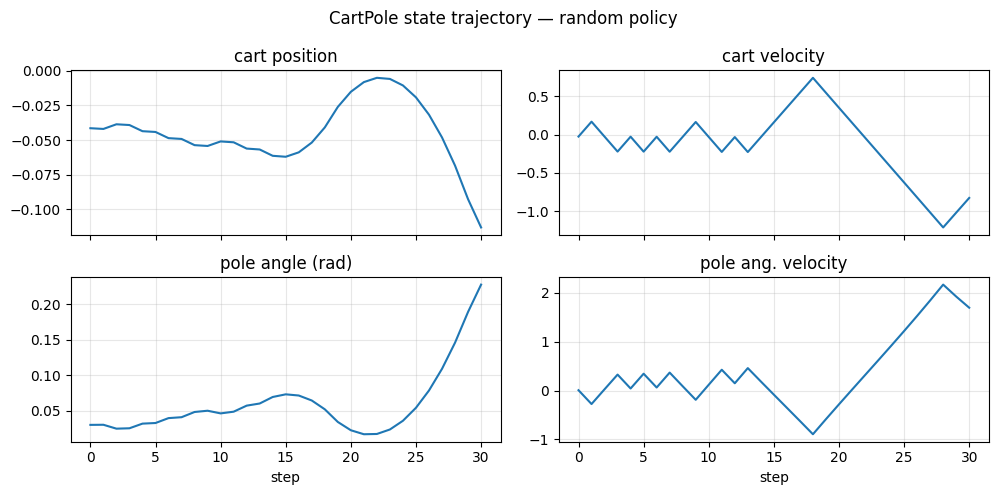

In [23]:
cp = gym.make("CartPole-v1")
obs, info = cp.reset(seed=3)

history = [obs]
done = False
while not done:
    a = cp.action_space.sample()
    obs, r, term, trunc, info = cp.step(a)
    history.append(obs)
    done = term or trunc
history = np.array(history)
print(f"Episode ended after {len(history)} steps")
cp.close()

fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True)
labels = ["cart position", "cart velocity", "pole angle (rad)", "pole ang. velocity"]
for i, (ax, lbl) in enumerate(zip(axes.ravel(), labels)):
    ax.plot(history[:, i])
    ax.set_title(lbl)
    ax.grid(alpha=0.3)
axes[1, 0].set_xlabel("step")
axes[1, 1].set_xlabel("step")
fig.suptitle("CartPole state trajectory — random policy")
fig.tight_layout()
plt.show()

### Hand-coded heuristics vs random

A surprisingly effective heuristic on CartPole: **push in the direction the pole is falling**.
It won't reach 500 reliably (no cart-position term, so the cart can drift out of bounds),
but it easily beats random.

random                          return: mean=  20.07  std= 10.67  len: mean=  20.1
angle-only                      return: mean=  42.59  std=  8.68  len: mean=  42.6
angle+rate                      return: mean= 500.00  std=  0.00  len: mean= 500.0


/var/folders/6w/dz3fxtw116b6lkr2wxkwjz4m0000gn/T/ipykernel_83202/42653441.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([r_rand, r_lean, r_both], labels=["random", "angle-only", "angle+rate"])


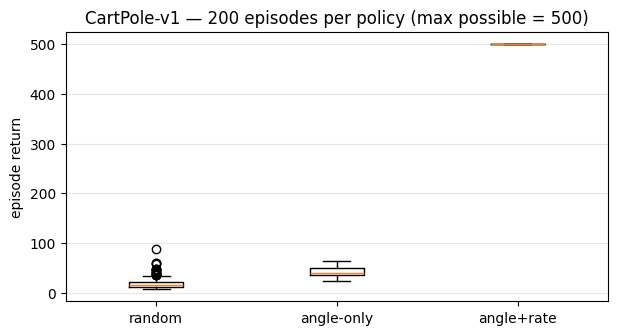

In [24]:
def random_action(obs):
    return int(rng.integers(0, 2))

def lean_heuristic(obs):
    """Push right (1) if pole is tilting right, else push left (0)."""
    return 1 if obs[2] > 0 else 0

def angle_and_rate(obs):
    """Look ahead one step: push in the direction of angle + k * angular velocity."""
    return 1 if obs[2] + 0.5 * obs[3] > 0 else 0

cp = gym.make("CartPole-v1")
N = 200
r_rand,  _ = summarize(rollout(cp, random_action,    n_episodes=N, seed=0), "random")
r_lean,  _ = summarize(rollout(cp, lean_heuristic,   n_episodes=N, seed=0), "angle-only")
r_both,  _ = summarize(rollout(cp, angle_and_rate,   n_episodes=N, seed=0), "angle+rate")
cp.close()

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.boxplot([r_rand, r_lean, r_both], labels=["random", "angle-only", "angle+rate"])
ax.set_ylabel("episode return")
ax.set_title(f"CartPole-v1 — {N} episodes per policy (max possible = 500)")
ax.grid(alpha=0.3, axis="y")
plt.show()

### Discretizing CartPole for tabular methods

If you want to apply Q-learning/SARSA to CartPole you must bin the continuous state.
A common scheme is 6–10 bins per dimension using the empirical range, clipping outliers.
Be aware: this creates a Q-table with `bins**4 * 2` entries and the curse of
dimensionality kicks in fast. Function approximation (DQN) usually wins here.

In [14]:
def make_discretizer(bins=(6, 6, 12, 12), low=None, high=None):
    low  = np.array(low  if low  is not None else [-2.4, -3.0, -0.21, -3.5])
    high = np.array(high if high is not None else [ 2.4,  3.0,  0.21,  3.5])
    edges = [np.linspace(l, h, b + 1)[1:-1] for l, h, b in zip(low, high, bins)]

    def to_idx(obs):
        return tuple(int(np.digitize(obs[i], edges[i])) for i in range(len(bins)))

    return to_idx, bins

to_idx, bins = make_discretizer()
cp = gym.make("CartPole-v1")
obs, _ = cp.reset(seed=0)
print(f"obs = {obs}\ndiscrete index = {to_idx(obs)}")
print(f"Q-table shape  = {bins + (2,)} -> {int(np.prod(bins) * 2)} cells")
cp.close()

obs = [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
discrete index = (3, 2, 4, 5)
Q-table shape  = (6, 6, 12, 12, 2) -> 10368 cells


---

## 7. Side-by-side summary

| Property | Blackjack-v1 | CartPole-v1 |
|----------|--------------|-------------|
| Obs space | `Tuple(Discrete(32), Discrete(11), Discrete(2))` | `Box(shape=(4,))` |
| State cardinality | ~280 meaningful states | Infinite (continuous) |
| Action space | `Discrete(2)` | `Discrete(2)` |
| Reward structure | Sparse, terminal only, ∈ {-1, 0, +1} | Dense, +1 per step |
| Episode length | 1–~10 steps | up to 500 |
| Termination | Bust, stick, dealer resolves | Pole falls / cart off-track |
| Truncation | Rare | At 500 steps (successful!) |
| Best class of agent | Tabular (Q-learning, MC control, SARSA) | Function-approx (DQN, PG, actor-critic) |
| Main difficulty | Stochasticity, credit assignment to a single action | Continuous state, long horizon |

## 8. Practical tips for the assignment

1. **Always pass `seed=` to `reset` at the start of training** and log the seed in your
   experiment config. Do several runs with different seeds and report mean ± std — a
   single seed is not a result in RL.
2. **Keep training and evaluation envs separate.** Typical pattern: `train_env` with
   exploration noise, `eval_env` with greedy policy, called every N episodes.
3. **Use `RecordEpisodeStatistics`** so you never have to hand-accumulate returns inside
   the training loop — `info["episode"]["r"]` and `info["episode"]["l"]` are populated on
   terminal steps.
4. **`terminated` vs `truncated` matters for bootstrapping.** For CartPole: when
   `truncated and not terminated`, still bootstrap `V(s')`. For Blackjack it doesn't really
   come up — episodes always terminate.
5. **Know your Q-table shape.** For Blackjack: `(32, 11, 2, 2)` works; you can also strip
   unreachable states to `(10, 10, 2, 2)` if you like. For CartPole-discretized: pick
   ~6 bins per dim to start.
6. **Don't trust `observation_space.high`** on CartPole for normalization — use empirical
   stats or `NormalizeObservation`.
7. **Vectorize when you hit GPU throughput limits**, not before. For tabular stuff it's
   overkill; for DQN with a small net it's often not worth the added complexity; for
   PPO it's practically required.

### Further reading

- Gymnasium docs: <https://gymnasium.farama.org/>
- Blackjack env page: <https://gymnasium.farama.org/environments/toy_text/blackjack/>
- CartPole env page: <https://gymnasium.farama.org/environments/classic_control/cart_pole/>
- API migration from Gym: <https://gymnasium.farama.org/introduction/migration_guide/>